# <center> Learning Phase Boundaries of the Bose-Hubbard Model</center>
### <center> Liam Jones</center>
### <center> PHY 406 - Spring 2026</center>

In this project the superfluid–Mott insulator (SF–MI) phase boundary of the 2D Bose-Hubbard model is located using a fully unsupervised machine learning method that takes the ground-state wavefunction as its sole input. Exact diagonalization is performed on three periodic square lattices — $2\!\times\!2$ ($M=4$ sites), $2\!\times\!3$ ($M=6$ sites), and $3\!\times\!3$ ($M=9$ sites) — each at unit filling ($N = M$). For each of 1000 interaction strengths $U/t \in [0.5, 40]$ the ground-state wavefunction $|\psi_0\rangle$ is computed and stored as a row of the dataset matrix $\boldsymbol{\Psi} \in \mathbb{R}^{1000 \times D}$. The largest system studied, $3\!\times\!3$ ($D = 24310$), is used as the representative example throughout the Results section. The unsupervised classifier combines principal component analysis with a Gaussian Mixture Model (GMM): the mean-centered wavefunction matrix is projected onto its leading principal components, and a 2-component GMM clusters the trajectories in PC space. The Mott cluster is identified as the component with the higher mean $U/t$, and the phase boundary is placed at $P(\text{Mott}\,|\,\psi) = 0.5$. A system-size comparison across all three lattices is presented after the main results.

In [21]:
from IPython.display import Image, display
import os
output_dir = os.path.join(os.path.dirname(os.path.abspath("LearningPhaseBoundaries.ipynb")), "output")
def show(filename, width):
    path = os.path.join(output_dir, filename)
    display(Image(filename=path, width=width))

## Theory

The Bose-Hubbard model is a bosonic tight binding model which is mostly known in condensed matter for its paradigmatic demonstration of the BKT phase transition from superfluidity to a Mott insulator phase. Its physics have even been realized experimentally using optical lattices, which have applications in certain trapped ion and neutral atom quantum computing architectures. The Bose-Hubbard Hamiltonian in the lattice-site Fock basis $\{|n_i\rangle\}$,
$$
H_{\text{BH}} = -t\sum_{\langle i,j\rangle} \left(b^{\dagger}_ib_j + b_ib^{\dagger}_j\right) + \frac{U}{2}\sum_i n_i(n_i-1) - \mu\sum_i n_i,
$$
describes interacting spinless bosons on a lattice of $M$ sites. In the canonical ensemble, the number of particles $N$ is fixed and the chemical potential term serves only to shift the energy by a constant. The kinetic/hopping term is a sum over nearest neighbors $\langle i,j\rangle$, which can be determined from the lattice adjacency matrix. Boundary conditions further determine allowed hoppings beyond the lattice geometry, where generically the coordination number of each site is uniform if periodic boundary conditions are assumed. Open boundaries can create significant effects for finite systems due to breaking of translational symmetry, which can be observed as, for example, Friedel oscillations in the ground state density. Conventionally, the repulsive on-site interaction is expressed as $U/t$. The on-site density is given by $n_i = b^{\dagger}_ib_i$, with $b^{\dagger}_i$ ($b_i$) the bosonic creation (annihilation) operators on site $i$. These obey the bosonic commutation relation $\left[b_i,b^{\dagger}_i\right]=\delta_{ij}$ and appear in the kinetic term in pairs as hopping operators.

The Hilbert space for $N$ indistinguishable bosons on $M$ sites has dimension
$$
D = \binom{N+M-1}{N}.
$$
For the three lattices studied here at unit filling:

| Lattice | $M$ | $N$ | $D$ |
|---------|-----|-----|-----|
| $2\!\times\!2$ | 4 | 4 | 35 |
| $2\!\times\!3$ | 6 | 6 | 462 |
| $3\!\times\!3$ | 9 | 9 | 24310 |

The $3\!\times\!3$ system ($D = 24310$) is the primary example in the Results section. At this dimension, the ground state is computed efficiently by the implicitly-restarted Arnoldi method (`Arpack.eigs`). For the smaller systems dense diagonalization would suffice, while much larger systems would reqiure quantum Monte Carlo simulations. A canonical sign convention is applied after diagonalization: the Fock-basis amplitude with the largest absolute value is required to be positive, fixing the global $U(1)$ phase ambiguity and ensuring each wavefunction is a unique real vector. After sign normalization, $|\langle\psi_0|\psi_0\rangle|^2 = 1$ is verified for every data point.

### Ground-State Wavefunction as a Phase Indicator

The SF–MI transition is encoded directly in the structure of $|\psi_0\rangle$ without computing any derived observable. For the $3\!\times\!3$ lattice at unit filling ($D = 24310$):

| Limit | Wavefunction character | Fock fidelity $F = \max_i\lvert\psi_i\rvert^2$ |
|---|---|---|
| Deep SF ($U/t \to 0$) | Broad superposition over all $D = 24310$ Fock states | $F \approx 1/D \approx 4\times10^{-5}$ |
| Deep MI ($U/t \to \infty$) | Concentrated on $\lvert1,1,\ldots,1\rangle$ | $F \approx 1$ |

The Fock-state fidelity $F$ is a natural, physics-informed order parameter that interpolates monotonically between the two limits. In the ML pipeline it serves only as post-hoc validation — it is computed from the same wavefunctions but is never used to assign labels or train the model. The evolution from the delocalized SF state to the localised MI state occurs via a rapid crossover in a narrow window of $U/t$ near the phase boundary. PCA detects this as a sharp change in the geometry of the 1000-point data trajectory through $\mathbb{R}^D$.

## Methods

### Dataset

Exact diagonalization is performed at 1000 uniformly spaced values of $U/t \in [0.5, 40]$ on each of three periodic square lattices at unit filling:

| Lattice | $M$ | $N$ | $D$ | Dataset shape |
|---------|-----|-----|-----|---------------|
| $2\!\times\!2$ | 4 | 4 | 35 | $1000 \times 35$ |
| $2\!\times\!3$ | 6 | 6 | 462 | $1000 \times 462$ |
| $3\!\times\!3$ | 9 | 9 | 24 310 | $1000 \times 24310$ |

For each system the raw amplitude matrix $\boldsymbol{\Psi}$ is the sole input to the classifier. No observable is extracted and no label is assigned. The grid spans from deep in the superfluid ($U/t = 0.5$) to deep in the Mott insulator ($U/t = 40$), ensuring that both limiting phases are well represented. Detailed results throughout this section are shown for the $3\!\times\!3$ lattice; finite-size comparisons across all three systems appear in the System-Size Comparison section.

### PCA + Gaussian Mixture Model

Each wavefunction vector $\psi \in \mathbb{R}^D$ is mean-centered column-wise, subtracting the mean amplitude $\bar{\psi}_j = \frac{1}{1000}\sum_{k=1}^{1000}\psi_{kj}$ at each Fock state $j$. Mean-centering without per-feature variance normalization is appropriate because all Fock-basis amplitudes share the same physical units; variance normalization would artificially amplify noise in rarely-occupied Fock states whose amplitudes are near zero throughout the sweep. The $1000 \times D$ centered matrix is decomposed by truncated SVD, $\tilde{\boldsymbol{\Psi}} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$, where the columns of $\mathbf{V}$ are the principal axes (eigenvectors of the sample covariance) and the diagonal entries of $\boldsymbol{\Sigma}$ are proportional to the PC standard deviations. Fifty PCs are retained, capturing the vast majority of the variance; the rapid decay of the explained-variance spectrum confirms that the 1000-point $U/t$ trajectory lies on an intrinsically low-dimensional manifold embedded in $\mathbb{R}^D$.

A 2-component Gaussian Mixture Model with full covariance matrices is fit to the projections onto the first 10 PCs. Full (unconstrained) covariance is chosen over diagonal or spherical variants because the PC scores can exhibit non-trivial correlations, particularly near the phase boundary where wavefunctions interpolate between the two limiting geometries. The model posits that each data point $\mathbf{z} \in \mathbb{R}^{10}$ (the PC-score vector) is drawn from a mixture of two Gaussians,

$$
p(\mathbf{z}) = \pi_{\text{SF}}\,\mathcal{N}(\mathbf{z};\boldsymbol{\mu}_{\text{SF}}, \boldsymbol{\Sigma}_{\text{SF}}) + \pi_{\text{MI}}\,\mathcal{N}(\mathbf{z};\boldsymbol{\mu}_{\text{MI}}, \boldsymbol{\Sigma}_{\text{MI}}),
$$

where $\pi_\alpha$ are the mixing weights. Parameters $\{\pi_\alpha, \boldsymbol{\mu}_\alpha, \boldsymbol{\Sigma}_\alpha\}$ are estimated by the Expectation–Maximization (EM) algorithm, which alternates between computing soft cluster assignments (E-step) and updating the component parameters to maximize the expected log-likelihood (M-step) until convergence. Because the EM objective is non-convex, 20 random initializations of the component means are used and the run with the highest converged log-likelihood is retained to mitigate convergence to local optima. The posterior probability of a wavefunction belonging to the Mott component follows from Bayes' theorem,

$$
P(\text{MI}\,|\,\mathbf{z}) = \frac{\pi_{\text{MI}}\,\mathcal{N}(\mathbf{z};\boldsymbol{\mu}_{\text{MI}}, \boldsymbol{\Sigma}_{\text{MI}})}{p(\mathbf{z})},
$$

and varies continuously from 0 (deep SF) to 1 (deep MI). The two components are assigned physical labels post hoc: the MI component is the cluster whose member wavefunctions have the higher mean $U/t$ — no label information enters the fitting procedure. The phase boundary is located at the crossing $P(\text{MI}\,|\,\psi) = 0.5$, found by linear interpolation between the two bracketing grid points.

## Results

### PCA Analysis

The scree plot (top figure) shows that the wavefunction data is highly low-dimensional: the first PC alone captures the bulk of the total variance, and the spectrum decays rapidly thereafter. This compression is physically meaningful — the entire 1000-point $U/t$ trajectory is driven by a single control parameter, so the dominant mode of variation is the coherent evolution from the delocalized SF wavefunction to the localized MI wavefunction. The sharp elbow in the spectrum separates the physically informative modes (PCs 1–10, used in the GMM) from the residual noise floor, confirming that 10 PCs is a well-motivated truncation.

The scatter plot (bottom figure) maps each of the 1000 wavefunctions to a point in the plane of the two leading PCs. The data resolve into two compact, well-separated lobes with a narrow transition corridor between them. Points colored by the GMM assignment (blue = SF, red = MI) show that the two components align cleanly with the two phases: the SF lobe occupies the negative-PC-1 half-plane, where wavefunctions are broad superpositions over many Fock states, while the MI lobe sits at large positive PC 1, where weight is concentrated on the unit-filling Fock state $|1,1,\ldots,1\rangle$. The elongation of each lobe along PC 1 reflects the continuous evolution within each phase as $U/t$ is varied, while the displacement along PC 2 encodes secondary structural differences — notably the gradual suppression of number fluctuations as the system approaches the Mott limit. The approximately elliptical, Gaussian geometry of each lobe provides post-hoc justification for the full-covariance GMM prior, and the clean separation confirms that the 10-PC representation is sufficient to discriminate the phases without supervision.

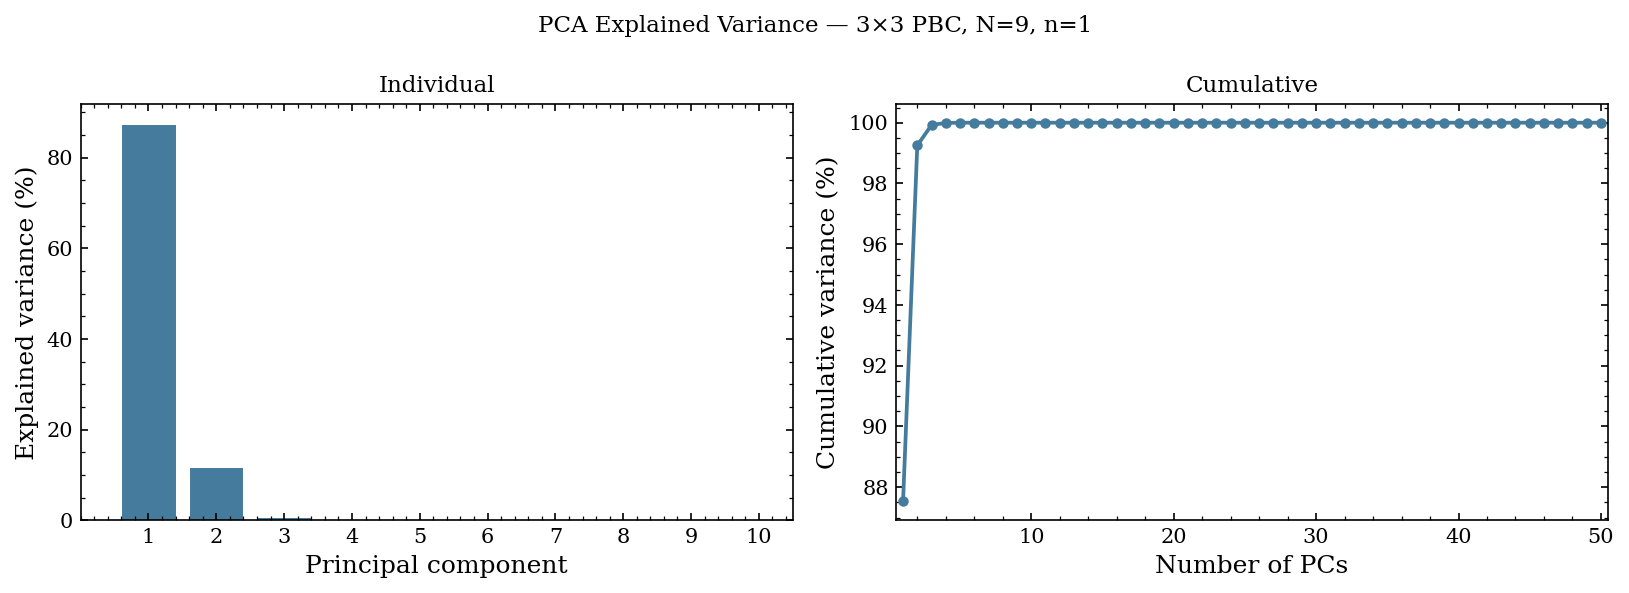

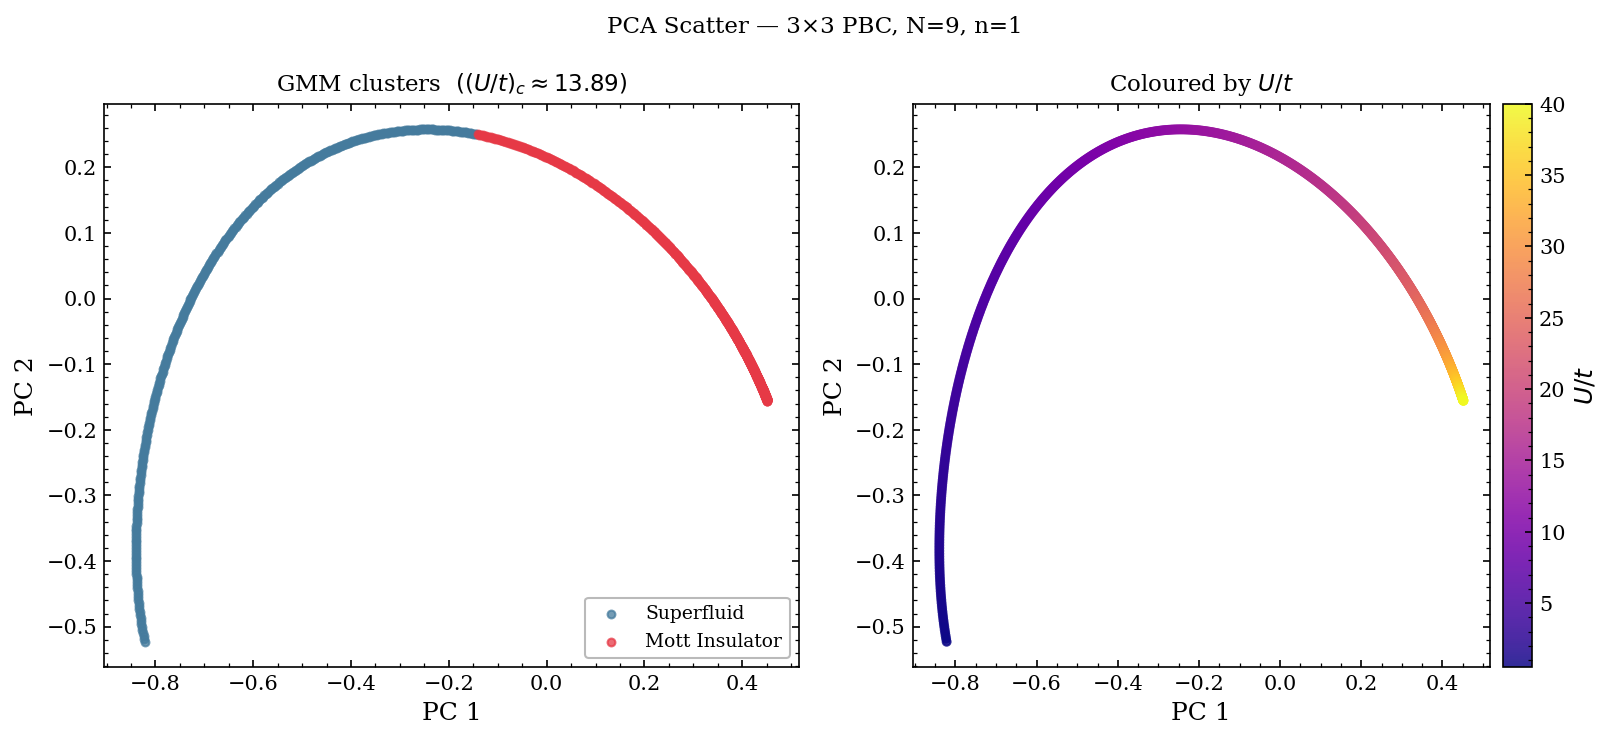

In [24]:
show("pca_variance_Lx3_Ly3_n9.png",1000)
show("pca_scatter_Lx3_Ly3_n9.png",1000)

The trajectory of PC 1 as a function of $U/t$ (below) encodes the primary structural evolution of the wavefunction across the phase diagram. In the deep SF regime ($U/t \lesssim 5$) the PC 1 score is large and negative, reflecting the broad Fock-space superposition that maximally distinguishes the SF from the MI. As $U/t$ increases the score rises steeply through an inflection point near the critical coupling — the hallmark of a sharp crossover encoded as a rapid change of direction in PC space — before saturating at a large positive value in the deep MI ($U/t \gtrsim 25$). The inflection point, identified by the GMM posterior crossing $P(\text{MI}\,|\,\psi) = 0.5$, is the machine-learning estimate of $(U/t)_c$. The near-monotonic character of the PC 1 trajectory across the full sweep confirms that the first mode captures the global SF–MI order: it is a machine-discovered proxy for the Fock-state fidelity $F$, extracted without any prior physical knowledge.

PC 2 exhibits a lower-amplitude, non-monotonic profile with a local extremum near the transition. This behavior reflects second-order structural changes in the wavefunction — such as the redistribution of weight among doubly-occupied Fock states that accompanies the suppression of number fluctuations — which do not contribute to the leading trend but break the degeneracy between wavefunctions that have identical PC 1 scores but differ structurally within their respective phases. When all 10 PCs are supplied to the GMM, their collective geometry refines the decision boundary beyond what PC 1 alone could achieve, particularly in the transition corridor where wavefunctions from neither limiting phase dominate and the posterior varies most rapidly.

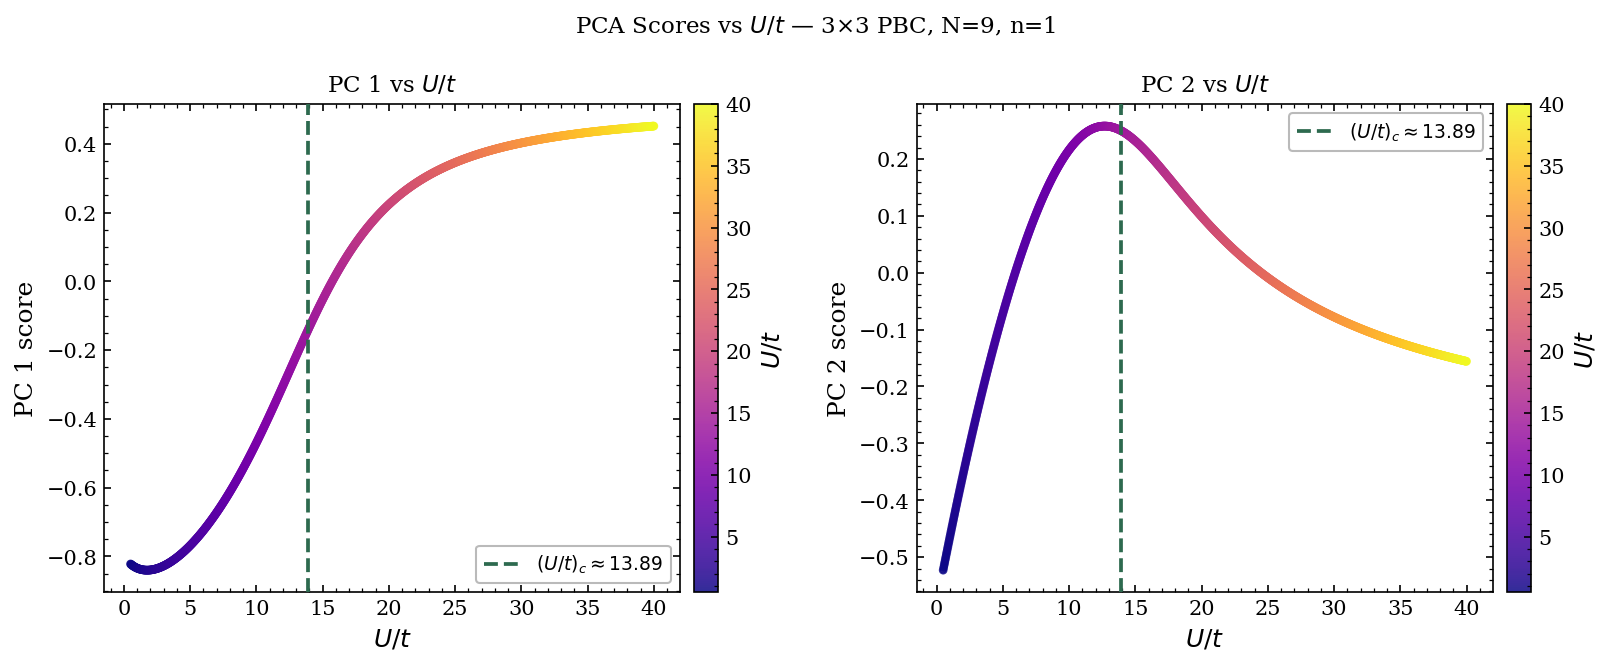

In [25]:
show("pca_trajectory_Lx3_Ly3_n9.png", 1000)

### Physical Order Parameter

The Fock-state fidelity $F(U/t) = \max_i|\psi_i|^2$ provides an independent, physics-derived validation of the ML result. It evolves monotonically from $F \approx 1/D \approx 4\times10^{-5}$ in the deep superfluid to $F \approx 1$ in the deep Mott insulator. The rapid crossover coincides precisely with the PCA+GMM-detected boundary, confirming that the GMM is clustering the physically correct signal in wavefunction space.

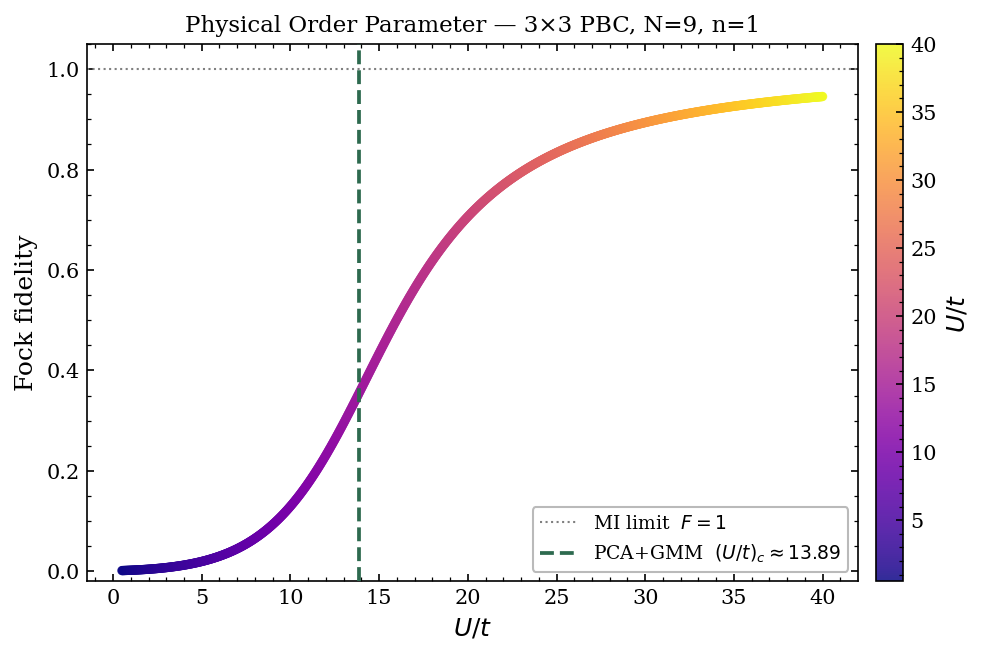

In [26]:
show("order_parameter_Lx3_Ly3_n9.png", 600)

### Phase Boundary Results

The boundary-comparison figure overlays $P(\text{Mott}\,|\,\psi)$ from PCA+GMM alongside the normalised Fock fidelity. The posterior curve exhibits a sharp sigmoid-like transition with a well-defined crossing at $P = 0.5$.

For the $3\!\times\!3$ system at unit filling the result is:

| Method | $(U/t)_c$|
|--------|-------------------|
| PCA + GMM | $\approx 13.89$ |
| QMC (thermo. limit) | $16.74$ |

The estimate lies below the thermodynamic-limit QMC value $(U/t)_c \approx 16.74$. This downward finite-size shift is expected: quantum fluctuations are enhanced in small periodic systems, broadening the crossover and moving it to lower $U/t$. The QMC value plays no role in the detection algorithm.

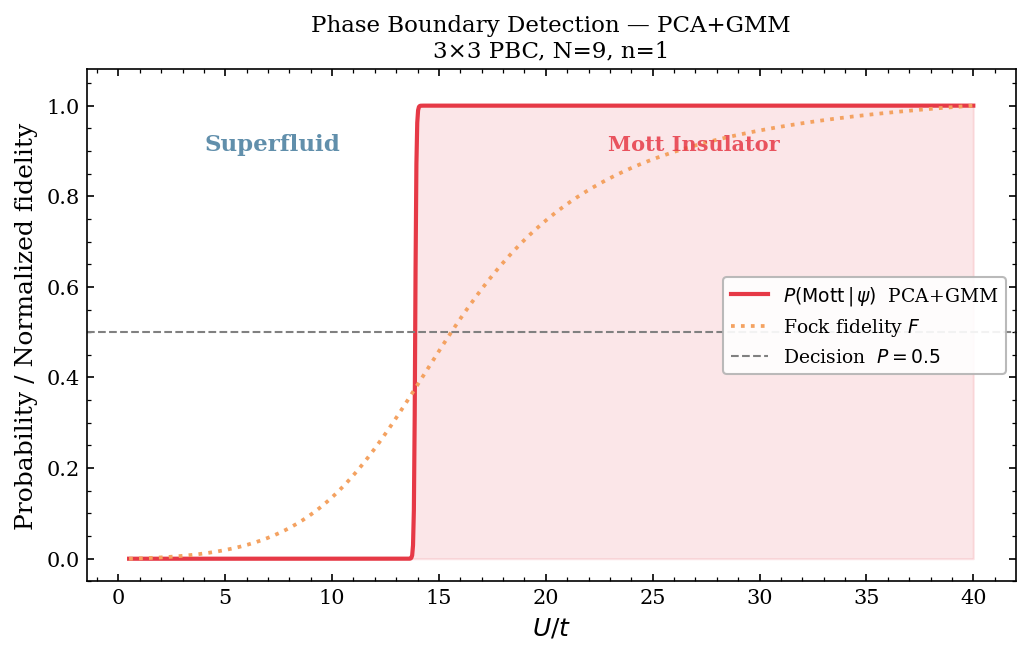

In [27]:
show("boundary_comparison_Lx3_Ly3_n9.png", 600)

### System-Size Comparison

To assess finite-size effects, PCA+GMM is applied to all three lattices at unit filling. The left panel of the figure below shows the detected $(U/t)_c$ as a function of inverse system size $1/M$; the dashed horizontal line marks the QMC thermodynamic-limit reference $(U/t)_c \approx 16.74$. A correctly performing classifier should produce estimates that trend upward towards the QMC value as $M$ increases ($1/M \to 0$). The right panel quantifies the absolute deviation of each estimate from the QMC reference.

Detected boundaries at unit filling:

| Lattice | $M$ | PCA+GMM |
|---------|-----|---------|
| $2\!\times\!2$ | 4 | $\approx 12.90$ |
| $2\!\times\!3$ | 6 | $\approx 13.35$ |
| $3\!\times\!3$ | 9 | $\approx 13.89$ |
| QMC (thermo. limit) | $\infty$ | $16.74$ |

PCA+GMM shows the expected finite-size trend: the detected boundary increases monotonically with $M$ and approaches the thermodynamic-limit value from below, consistent with enhanced quantum fluctuations reducing the effective critical coupling in small systems. Boundary detection has also been carried out for the smaller lattices at higher fillings, requiring an increase in the upper bound on $U/t$ to ensure a sufficient fraction of Mott phase samples. For $n=2,\, 3$ the critical interaction strength increases roughly linearly with filling and the $2\!\times\!3$ lattice consistently has higher values than the $2\!\times\!2$ system across all fillings. This is consistent with the Mott lobe structure, though finite-size effects similarly contribute to lower values.

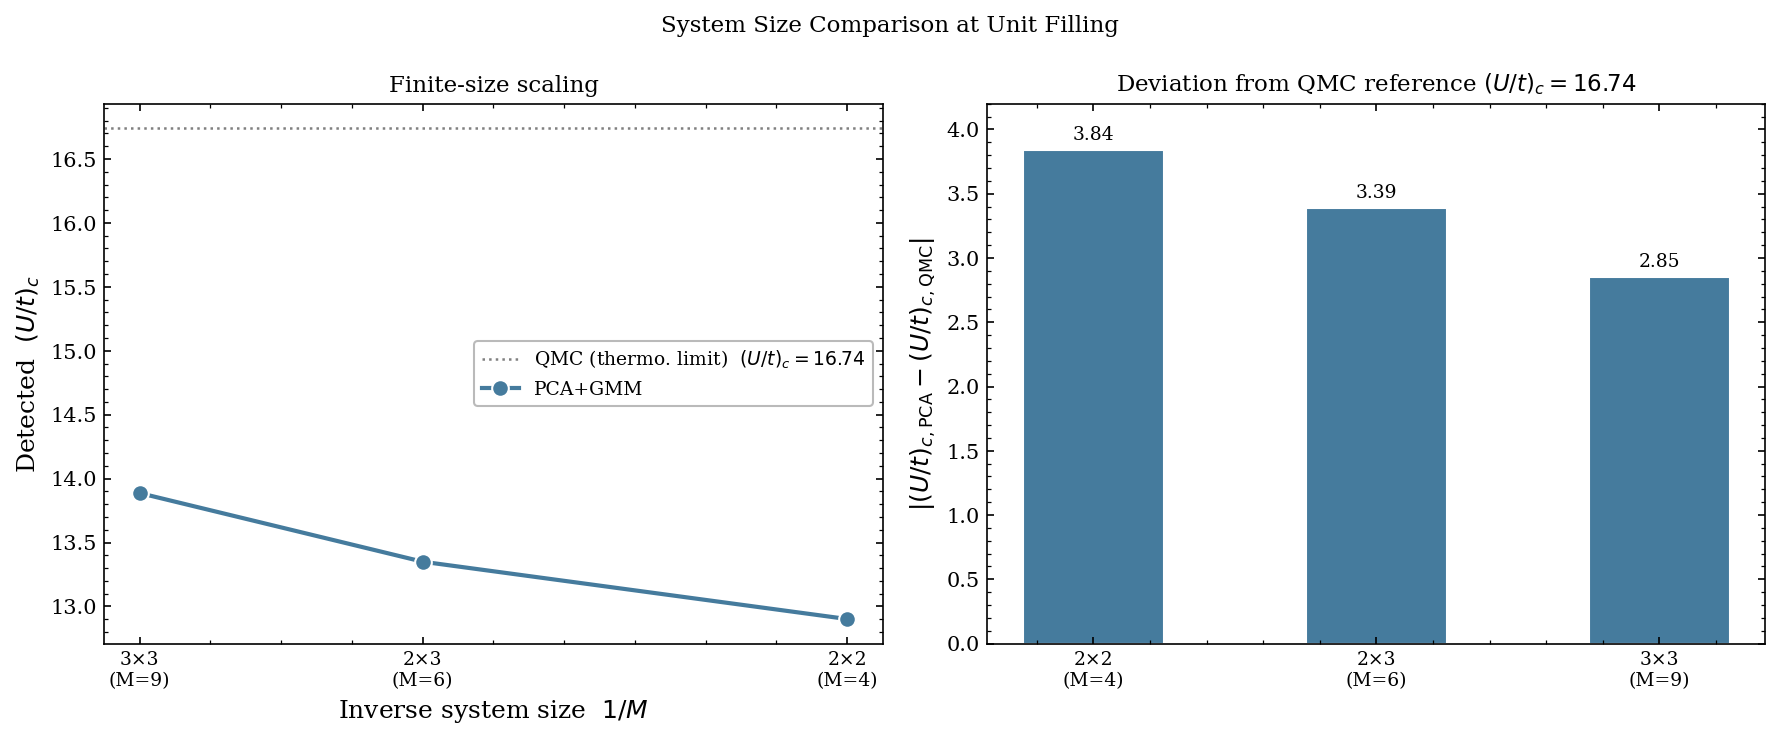

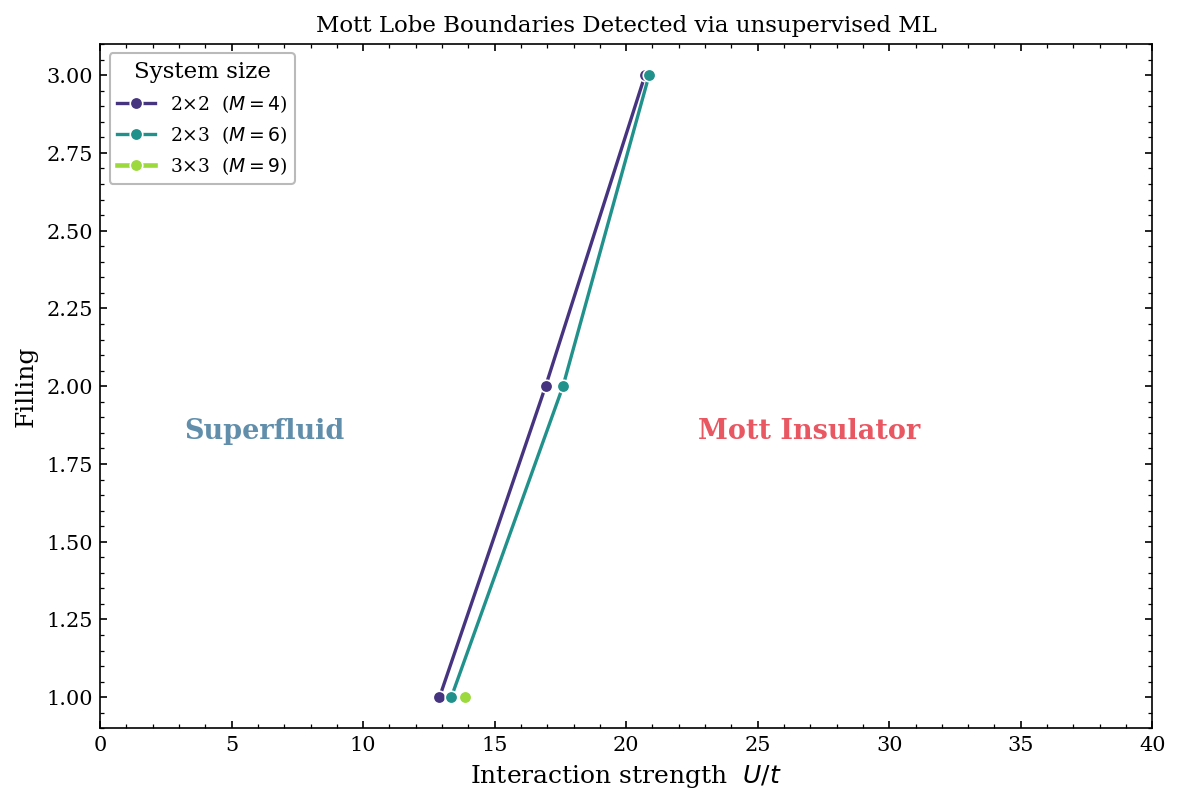

In [41]:
show("system_comparison_n1.png", width=1000)
show("mott_lobes.png", 600)

### Limitations

1. **Finite-size effects.** The most significant quantitative limitation is the systematic downward shift of the detected phase boundary relative to the thermodynamic limit. At unit filling the three lattices yield deviations of $3.84$, $3.39$, and $2.85$ from the QMC reference of $16.74$, corresponding to $17$–$23\%$ errors. The deviations grow substantially for higher fillings: the $n=2$ boundaries ($\approx 17.0$ and $17.6$ on the two smallest lattices) and $n=3$ boundaries ($\approx 20.7$ and $20.9$) fall far short of their thermodynamic-limit values, estimated from the mean-field scaling $(U/t)_c^{(n)} = 2z(2n+1)\cdot\kappa$ (where $z=4$ is the coordination number and $\kappa \approx 0.70$ is the QMC correction to mean-field, fixed by the $n=1$ result) as $\approx 28$ for $n=2$ and $\approx 39$ for $n=3$ — giving relative errors of $\sim 40$–$50\%$.

   The physical origin is the rounding of the sharp quantum phase transition by finite-system fluctuations: on a periodic lattice of $M$ sites there is no thermodynamic singularity at any finite $U/t$; the SF–MI transition is replaced by a smooth, analytic crossover whose midpoint sits below the true critical coupling. The deviation obeys a finite-size scaling law $(U/t)_c(L) - (U/t)_c(\infty) \propto L^{-1/\nu}$, where $L=\sqrt{M}$ is the linear size and $\nu \approx 0.671$ is the correlation-length exponent of the $(2{+}1)$-dimensional XY universality class (the appropriate class at the tip of the Mott lobe at commensurate filling). Extrapolating the three $n=1$ points against $M^{-1/(2\nu)}$ gives $(U/t)_c(\infty) \approx 15.0$, still $\sim 10\%$ below QMC, indicating that the smallest lattices ($M=4$, $6$) lie outside the asymptotic scaling regime and that a reliable extrapolation requires at least $4\!\times\!4$ and $4\!\times\!5$ systems.

2. **Scalability of exact diagonalization.** The Hilbert space dimension grows combinatorially: at unit filling $D \approx 4^M/\sqrt{\pi M/2}$ by Stirling's approximation, reaching $24310$ at $M=9$, $\approx 1.4\times10^6$ at $M=12$, and $\approx 7.8\times10^7$ at $M=15$. Sparse Lanczos methods (as used here) extend the range to roughly $M\sim15$–$20$ sites, but the $4\!\times\!4$ lattice ($M=16$, $D\approx6\times10^8$) is already at the edge of practical memory. At higher fillings the growth is steeper still: for $n=3$ on a $3\!\times\!4$ lattice ($N=36$, $M=12$) the dimension is $D\approx5\times10^{10}$, which is entirely intractable for ED. Extending finite-size scaling to the lattice sizes needed for a reliable thermodynamic-limit extrapolation therefore requires quantum Monte Carlo (QMC). The PCA+GMM pipeline could in principle be ported to QMC data by replacing the exact wavefunction amplitudes with estimators of the reduced density matrix or by training on sampled Fock-basis configurations, but this would require a non-trivial reformulation of both the feature space and the unsupervised clustering step.

3. **Canonical ensemble and access to only the lobe tip.** All simulations fix the particle number $N$ at integer multiples of $M$, placing the system precisely at the commensurate filling corresponding to the tip of each Mott lobe. PCA+GMM therefore returns only the critical coupling $(U/t)_c$ at the lobe tip — the maximum hopping strength at which the Mott phase is stable for that filling — rather than the full lobe boundary as a function of chemical potential $\mu$. Mapping the complete lobe shape in the $(U/t,\,\mu/U)$ plane would require grand-canonical simulations that scan over $\mu$ at fixed $U/t$, or equivalently simulations at non-integer mean filling. This is straightforward in QMC but requires additional structure in ED (working in a larger Fock space with variable particle number), and the PCA feature representation would need to account for wavefunctions with different normalization sectors.